# GRU-Based VAE Pretraining
Here we will pretrain a VAE using an architecture very similar to the Gómez-Bombarelli / `molecular-vae` style but instead uses a GRU encoder + GRU decoder. Another key change is that we will now use SELFIES instead of SMILES.

We will train a model on ChemBL + Zinc.


### Imports and config

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import selfies as sf

try:
    import wandb
except ImportError:
    wandb = None

SEED = 42
MAX_LEN = 120  
VAL_FRAC = 0.10
TEST_FRAC = 0.10

LATENT_DIM = 292
EPOCHS = 50           
BATCH_SIZE = 128
LR = 3e-4             
KL_ANNEAL_EPOCHS = 25 
FREE_BITS_NATS = 0.5  
TEACHER_FORCING_RATIO = 0.5  

USE_WANDB = False 
WANDB_PROJECT = "ai-for-toxicology"
WANDB_RUN_NAME = "pretrain-chembl-zinc-seqconv"

CHECKPOINT_DIR = Path("artifacts") / "pretraining_checkpoints"
CHECKPOINT_STEM = "paper_like_selfies_chembl_zinc_seqconv_ce"
SAVE_EPOCH_CHECKPOINTS = True  # Set False if disk usage becomes too high.

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda devices:", torch.cuda.device_count())
print("current device:", torch.cuda.current_device() if torch.cuda.is_available() else None)
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))


device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
print("device:", device)
print("torch:", torch.__version__)
print("selfies:", sf.__version__)
print("wandb:", "available" if wandb is not None else "not installed (optional)")

torch: 2.5.1+cu121
cuda available: True
cuda devices: 1
current device: 0
device name: NVIDIA GeForce RTX 2070
device: cuda
torch: 2.5.1+cu121
selfies: 2.1.1
wandb: available


### Load ChemBL and Zinc datasets

In [3]:
DATA_ROOT = Path("data")
CHEMBL_PATH = DATA_ROOT / "Train" / "chembl_clean.csv"
ZINC_PATH = DATA_ROOT / "Train" / "zinc250k_clean.csv"

for p in [CHEMBL_PATH, ZINC_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")


def load_smiles(path: Path) -> list[str]:
    df = pd.read_csv(path)
    if "canonical_smiles" not in df.columns:
        raise ValueError(f"{path} does not contain canonical_smiles")
    smiles = df["canonical_smiles"].dropna().astype(str).tolist()
    return list(dict.fromkeys(smiles))


chembl_smiles = load_smiles(CHEMBL_PATH)
zinc_smiles = load_smiles(ZINC_PATH)
pretrain_smiles = list(dict.fromkeys(chembl_smiles + zinc_smiles))

print(f"ChemBL unique SMILES: {len(chembl_smiles):,}")
print(f"Zinc unique SMILES:   {len(zinc_smiles):,}")
print(f"Combined unique SMILES for pretraining: {len(pretrain_smiles):,}")


ChemBL unique SMILES: 23,871
Zinc unique SMILES:   249,455
Combined unique SMILES for pretraining: 273,321


### Convert to SELFIES and create the combined pretraining split

In [4]:
def smiles_to_selfies(smiles_list: list[str]) -> tuple[list[str], int]:
    out = []
    failed = 0
    for smi in smiles_list:
        try:
            out.append(sf.encoder(smi))
        except Exception:
            failed += 1
    return out, failed


def filter_selfies_len(selfies_list: list[str], max_len: int = MAX_LEN) -> list[str]:
    return [s for s in selfies_list if len(list(sf.split_selfies(s))) <= max_len]


def split_list(items: list[str], val_frac: float, test_frac: float, seed: int) -> tuple[list[str], list[str], list[str]]:
    rng = np.random.default_rng(seed)
    idx = np.arange(len(items))
    rng.shuffle(idx)

    n = len(items)
    n_test = max(1, int(round(n * test_frac)))
    n_val = max(1, int(round(n * val_frac)))

    if n_test + n_val >= n:
        n_test = max(1, n // 10)
        n_val = max(1, n // 10)

    test_idx = idx[:n_test]
    val_idx = idx[n_test:n_test + n_val]
    train_idx = idx[n_test + n_val:]

    train = [items[i] for i in train_idx]
    val = [items[i] for i in val_idx]
    test = [items[i] for i in test_idx]
    return train, val, test


pretrain_selfies, pretrain_failed = smiles_to_selfies(pretrain_smiles)
pretrain_selfies = filter_selfies_len(pretrain_selfies, max_len=MAX_LEN)
train_selfies, val_selfies, test_selfies = split_list(pretrain_selfies, VAL_FRAC, TEST_FRAC, seed=SEED)

print(f"SELFIES conversion failures: {pretrain_failed}")
print(
    f"filtered combined split sizes: train={len(train_selfies):,}, "
    f"val={len(val_selfies):,}, test={len(test_selfies):,}"
)


SELFIES conversion failures: 0
filtered combined split sizes: train=218,336, val=27,292, test=27,292


### Tokenization and encoding

In [5]:
PAD = "<PAD>"
UNK = "<UNK>"
EOS = "<EOS>"


def tokenize_selfies(s: str) -> list[str]:
    return list(sf.split_selfies(s))


train_tokens = [tokenize_selfies(s) for s in train_selfies]
vocab_tokens = sorted({tok for seq in train_tokens for tok in seq})
ALL_TOKENS = [PAD, UNK, EOS] + vocab_tokens
TOKEN_TO_IDX = {tok: i for i, tok in enumerate(ALL_TOKENS)}
IDX_TO_TOKEN = {i: tok for tok, i in TOKEN_TO_IDX.items()}

PAD_IDX = TOKEN_TO_IDX[PAD]
UNK_IDX = TOKEN_TO_IDX[UNK]
EOS_IDX = TOKEN_TO_IDX[EOS]

SEQ_LEN = MAX_LEN + 1
VOCAB_SIZE = len(ALL_TOKENS)

if SEQ_LEN < 29:
    raise ValueError("Sequence length is too small for conv kernels (9, 9, 11).")


def encode_selfies(s: str) -> list[int]:
    ids = [TOKEN_TO_IDX.get(tok, UNK_IDX) for tok in tokenize_selfies(s)]
    ids = ids[:MAX_LEN]
    ids.append(EOS_IDX)
    return ids


def encode_list(selfies_list: list[str]) -> np.ndarray:
    out = np.full((len(selfies_list), SEQ_LEN), PAD_IDX, dtype=np.int64)
    for i, s in enumerate(selfies_list):
        ids = encode_selfies(s)
        out[i, :len(ids)] = ids
    return out


train_x = encode_list(train_selfies)
val_x = encode_list(val_selfies)
test_x = encode_list(test_selfies)

print(f"train={train_x.shape}, val={val_x.shape}, test={test_x.shape}")
print(f"VOCAB_SIZE={VOCAB_SIZE}, SEQ_LEN={SEQ_LEN}")

train=(218336, 121), val=(27292, 121), test=(27292, 121)
VOCAB_SIZE=115, SEQ_LEN=121


In [6]:
class TokenDataset(Dataset):
    def __init__(self, x: np.ndarray):
        self.x = torch.from_numpy(x).long()

    def __len__(self):
        return self.x.size(0)

    def __getitem__(self, idx):
        return self.x[idx]


### SELFIES VAE

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PaperLikeSelfiesVAE(nn.Module):
    def __init__(self, vocab_size: int, seq_len: int, latent_dim: int = 292):
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = seq_len
        self.latent_dim = latent_dim
        self.dec_hidden_size = 512 # Optimized for RTX 2070 memory

        # --- ENCODER (Robust Bidirectional GRU) ---
        self.embedding = nn.Embedding(vocab_size, 128) 
        self.encoder_gru = nn.GRU(
            input_size=128, 
            hidden_size=512, 
            num_layers=2, 
            batch_first=True, 
            bidirectional=True
        )
        self.enc_norm = nn.LayerNorm(1024) 
        self.linear_bottleneck = nn.Linear(1024, 512)
        self.mu_layer = nn.Linear(512, latent_dim)
        self.logvar_layer = nn.Linear(512, latent_dim)

        # --- DECODER (Autoregressive RNN structure) ---
        # 1. Map latent z to the initial hidden state of the decoder
        self.latent_to_h0 = nn.Linear(latent_dim, self.dec_hidden_size)
        
        # 2. Decoder GRU: Input is the previous token embedding (128)
        self.decoder_gru = nn.GRU(
            input_size=128, 
            hidden_size=self.dec_hidden_size, 
            num_layers=1, 
            batch_first=True
        )
        self.decoder_out = nn.Linear(self.dec_hidden_size, vocab_size)

    def encoder(self, x_ids: torch.Tensor):
        embedded = self.embedding(x_ids) 
        _, hidden = self.encoder_gru(embedded)
        # Concatenate Bi-GRU directions from the top layer
        cat_hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1) 
        x = F.selu(self.linear_bottleneck(self.enc_norm(cat_hidden)))
        return self.mu_layer(x), self.logvar_layer(x)

    def sampling(self, mean: torch.Tensor, logvar: torch.Tensor):
        std = torch.exp(0.5 * logvar)
        eps = 1e-2 * torch.randn_like(std) # Scaled for tighter latent clusters
        return mean + eps * std

    def decode(self, z: torch.Tensor, target_ids: torch.Tensor = None, teacher_forcing_ratio: float = 0.5):
        batch_size = z.size(0)
        
        # Seed the decoder hidden state with z
        h_t = self.latent_to_h0(z).unsqueeze(0) # [1, B, 512]
        
        # Start token (ID 0)
        decoder_input = torch.zeros(batch_size, 1, dtype=torch.long, device=z.device)
        all_logits = []

        for t in range(self.seq_len):
            # Forward step (similar to forward_step in your reference)
            embedded = self.embedding(decoder_input)
            output, h_t = self.decoder_gru(embedded, h_t)
            logits = self.decoder_out(output) # [B, 1, Vocab]
            all_logits.append(logits)

            # Determine next input
            use_teacher_forcing = True if (target_ids is not None and torch.rand(1).item() < teacher_forcing_ratio) else False
            
            if use_teacher_forcing:
                decoder_input = target_ids[:, t].unsqueeze(1)
            else:
                # Use model's own prediction (detached to break computational graph)
                decoder_input = logits.argmax(dim=-1).detach()

        return torch.cat(all_logits, dim=1)

    def forward(self, x_ids: torch.Tensor, teacher_forcing_ratio: float = 0.5):
        mean, logvar = self.encoder(x_ids)
        z = self.sampling(mean, logvar)
        logits = self.decode(z, target_ids=x_ids, teacher_forcing_ratio=teacher_forcing_ratio)
        return logits, mean, logvar

In [11]:
def vae_loss(
    logits: torch.Tensor,
    x_ids: torch.Tensor,
    mean: torch.Tensor,
    logvar: torch.Tensor,
    *,
    pad_idx: int,
    beta: float = 1.0,
    free_bits_nats: float = 0.0,
    eps_scale: float = 1e-2, # Added to match your new sampling logic
):
    vocab_size = logits.size(-1)
    
    # 1. Reconstruction Loss (Cross Entropy)
    # We use 'sum' to keep it compatible with the KL sum
    recon_sum = F.cross_entropy(
        logits.reshape(-1, vocab_size),
        x_ids.reshape(-1),
        ignore_index=pad_idx,
        reduction="sum",
    )

    # 2. KL Divergence
    # We must account for the eps_scale (0.01) used in sampling.
    # This prevents the KL term from overwhelming the scaled noise.
    scale_sq = eps_scale ** 2
    kl_per_dim = -0.5 * (1 + logvar + torch.log(torch.tensor(scale_sq)) - (mean.pow(2) + scale_sq * logvar.exp()))
    
    # 3. Apply Free Bits
    # This ensures each dimension contributes at least a little bit of info
    if free_bits_nats and free_bits_nats > 0:
        kl_per_dim = torch.clamp(kl_per_dim, min=float(free_bits_nats))
    
    kl_sum = kl_per_dim.sum()

    # 4. Normalization Helpers
    n_nonpad = (x_ids != pad_idx).sum().clamp(min=1)
    
    # Total loss weighted by Beta (KL Annealing)
    total = recon_sum + beta * kl_sum
    
    return total, recon_sum, kl_sum, n_nonpad

def kl_beta(epoch: int, anneal_epochs: int) -> float:
    """Stays the same for linear KL annealing."""
    if anneal_epochs <= 1:
        return 1.0
    return float(min(1.0, epoch / anneal_epochs))

### Training and evaluation helpers

In [14]:
def make_loader(x: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    return DataLoader(TokenDataset(x), batch_size=batch_size, shuffle=shuffle)


def init_wandb(*, run_name: str | None = None, epochs: int | None = None):
    if not USE_WANDB:
        return None
    if wandb is None:
        raise ImportError("wandb is not installed. Install it or set USE_WANDB=False.")

    return wandb.init(
        project=WANDB_PROJECT,
        name=run_name or WANDB_RUN_NAME,
        config={
            "seed": SEED,
            "max_len": MAX_LEN,
            "latent_dim": LATENT_DIM,
            "epochs": epochs if epochs is not None else EPOCHS,
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "kl_anneal_epochs": KL_ANNEAL_EPOCHS,
            "free_bits_nats": FREE_BITS_NATS,
            "vocab_size": VOCAB_SIZE,
            "seq_len": SEQ_LEN,
            "architecture": "bidirectional_gru_vae" # Updated for clarity
        },
    )

def run_epoch(model: nn.Module, loader: DataLoader, *, optimizer=None, beta: float = 1.0, tf_ratio: float = 0.5):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_sum, recon_sum, kl_sum = 0.0, 0.0, 0.0
    n_samples, n_nonpad, n_correct = 0, 0, 0

    for x_ids in loader:
        x_ids = x_ids.to(device)
        
        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            # Pass tf_ratio to the model's forward/decode method
            logits, mean, logvar = model(x_ids, teacher_forcing_ratio=tf_ratio if is_train else 0.0) 
            
            total, recon, kl, nonpad = vae_loss(
                logits,
                x_ids,
                mean,
                logvar,
                pad_idx=PAD_IDX,
                beta=beta,
                free_bits_nats=FREE_BITS_NATS,
            )
            
            if is_train:
                total.backward()
                # Gradient clipping is "sound" for RNNs to prevent explosions
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        mask = x_ids != PAD_IDX
        preds = logits.argmax(dim=-1)

        total_sum += total.item()
        recon_sum += recon.item()
        kl_sum += kl.item()
        n_samples += x_ids.size(0)
        n_nonpad += int(nonpad.item())
        n_correct += ((preds == x_ids) & mask).sum().item()

    return {
        "total": total_sum / max(n_samples, 1),
        "recon_per_token": recon_sum / max(n_nonpad, 1),
        "kl": kl_sum / max(n_samples, 1),
        "token_acc": n_correct / max(n_nonpad, 1),
    }

def evaluate(model: nn.Module, x: np.ndarray, *, beta: float):
    loader = make_loader(x, batch_size=BATCH_SIZE, shuffle=False)
    return run_epoch(model, loader, optimizer=None, beta=beta)


def _checkpoint_payload(
    model: nn.Module,
    history: dict,
    *,
    epoch: int,
    best_epoch: int | None,
    best_val_total: float | None,
    optimizer=None,
    test_metrics: dict | None = None,
):
    return {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "epoch": int(epoch),
        "best_epoch": int(best_epoch) if best_epoch is not None else None,
        "best_val_total": float(best_val_total) if best_val_total is not None else None,
        "token_to_idx": TOKEN_TO_IDX,
        "seq_len": SEQ_LEN,
        "vocab_size": VOCAB_SIZE,
        "max_len": MAX_LEN,
        "pad_idx": PAD_IDX,
        "unk_idx": UNK_IDX,
        "eos_idx": EOS_IDX,
        "history": history,
        "test_metrics": test_metrics,
        "encoder_layout": "bidirectional_gru_embedding", # Updated metadata
        "decoder_output": "logits",
        "loss_name": "token_cross_entropy_plus_kl",
    }


def _save_training_checkpoints(
    model: nn.Module,
    history: dict,
    *,
    save_dir: Path,
    checkpoint_stem: str,
    epoch: int,
    best_epoch: int | None,
    best_val_total: float | None,
    optimizer=None,
    is_best: bool,
    save_epoch_checkpoints: bool,
):
    payload = _checkpoint_payload(
        model,
        history,
        epoch=epoch,
        best_epoch=best_epoch,
        best_val_total=best_val_total,
        optimizer=optimizer,
        test_metrics=None,
    )

    last_path = save_dir / f"{checkpoint_stem}_last.pt"
    torch.save(payload, last_path)

    if save_epoch_checkpoints:
        epoch_path = save_dir / f"{checkpoint_stem}_epoch_{epoch:03d}.pt"
        torch.save(payload, epoch_path)

    if is_best:
        best_path = save_dir / f"{checkpoint_stem}_best.pt"
        torch.save(payload, best_path)

def train_model(
    train_x: np.ndarray,
    val_x: np.ndarray,
    *,
    model: nn.Module | None = None,
    optimizer=None,
    history: dict | None = None,
    start_epoch: int = 0,
    num_epochs: int = EPOCHS,
    checkpoint_dir: Path | None = None,
    checkpoint_stem: str | None = None,
    save_epoch_checkpoints: bool = SAVE_EPOCH_CHECKPOINTS,
    wandb_run_name: str | None = None,
    patience: int = 10,
    min_delta: float = 0.005
):
    if model is None:
        model = PaperLikeSelfiesVAE(vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, latent_dim=LATENT_DIM).to(device)
    
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    train_loader = make_loader(train_x, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = make_loader(val_x, batch_size=BATCH_SIZE, shuffle=False)

    if history is None:
        history = {k: [] for k in ["beta", "tf_ratio", "train_total", "val_total", "train_recon_per_token", 
                                   "val_recon_per_token", "train_kl", "val_kl", "train_token_acc", "val_token_acc"]}

    # --- INITIALIZATION FIXED ---
    best_val_recon = float("inf")
    best_val_total = float("inf")
    best_epoch = None
    stop_counter = 0
    
    wandb_run = init_wandb(run_name=wandb_run_name, epochs=num_epochs)

    for rel_ep in range(1, num_epochs + 1):
        ep = start_epoch + rel_ep
        beta = kl_beta(ep, KL_ANNEAL_EPOCHS)
        tf_ratio = max(0.1, 0.5 * (1 - (ep / num_epochs)))

        train_metrics = run_epoch(model, train_loader, optimizer=optimizer, beta=beta, tf_ratio=tf_ratio)
        val_metrics = run_epoch(model, val_loader, optimizer=None, beta=beta, tf_ratio=0.0)

        scheduler.step(val_metrics["total"])
        current_lr = optimizer.param_groups[0]['lr']

        # Update History
        history["beta"].append(beta)
        history["tf_ratio"].append(tf_ratio)
        history["train_total"].append(train_metrics["total"])
        history["val_total"].append(val_metrics["total"])
        history["train_recon_per_token"].append(train_metrics["recon_per_token"])
        history["val_recon_per_token"].append(val_metrics["recon_per_token"])
        history["train_kl"].append(train_metrics["kl"])
        history["val_kl"].append(val_metrics["kl"])
        history["train_token_acc"].append(train_metrics["token_acc"])
        history["val_token_acc"].append(val_metrics["token_acc"])

        # --- LOGIC UPDATED TO TRACK RECON ---
        if val_metrics["recon_per_token"] < best_val_recon - min_delta:
            best_val_recon = float(val_metrics["recon_per_token"])
            best_val_total = float(val_metrics["total"]) # Update total for metadata
            best_epoch = ep
            stop_counter = 0 
            is_best = True
        else:
            stop_counter += 1
            is_best = False

        print(
            f"Epoch {ep:03d} | β={beta:.2f} | TF={tf_ratio:.2f} | LR={current_lr:.2e}\n"
            f"  TRAIN: Total={train_metrics['total']:.4f} | Recon={train_metrics['recon_per_token']:.4f} | KL={train_metrics['kl']:.4f} | Acc={train_metrics['token_acc']:.4f}\n"
            f"  VALID: Total={val_metrics['total']:.4f} | Recon={val_metrics['recon_per_token']:.4f} | KL={val_metrics['kl']:.4f} | Acc={val_metrics['token_acc']:.4f}"
            + (" ⭐" if is_best else f" [Patience: {stop_counter}/{patience}]")
            + "\n" + "-"*80
        )

        if checkpoint_dir and checkpoint_stem:
            _save_training_checkpoints(model, history, save_dir=checkpoint_dir, checkpoint_stem=checkpoint_stem,
                                       epoch=ep, best_epoch=best_epoch, best_val_total=best_val_total,
                                       optimizer=optimizer, is_best=is_best, save_epoch_checkpoints=save_epoch_checkpoints)

        if wandb_run:
            wandb_run.log({
                "epoch": ep,
                "train/total": train_metrics["total"],
                "train/recon": train_metrics["recon_per_token"],
                "train/kl": train_metrics["kl"],
                "val/total": val_metrics["total"], 
                "val/recon": val_metrics["recon_per_token"],
                "val/kl": val_metrics["kl"],
                "val/token_acc": val_metrics["token_acc"],
                "lr": current_lr
            }, step=ep)

        if stop_counter >= patience:
            print(f"\nEarly stopping triggered. Best Reconstruction at Ep {best_epoch}")
            break

    if wandb_run: wandb_run.finish()
    return model, history, {"best_epoch": best_epoch, "best_val_total": best_val_total}

### Train the ChemBL + Zinc pretraining model

In [15]:
save_dir = CHECKPOINT_DIR
save_dir.mkdir(parents=True, exist_ok=True)

print("Training on the combined ChemBL + Zinc pretraining set...")
model, history, checkpoint_info = train_model(
    train_x,
    val_x,
    checkpoint_dir=save_dir,
    checkpoint_stem=CHECKPOINT_STEM,
    save_epoch_checkpoints=SAVE_EPOCH_CHECKPOINTS,
)

final_beta = history["beta"][-1]
test_metrics = evaluate(model, test_x, beta=final_beta)

# Keep the legacy single-checkpoint path for backwards compatibility.
ckpt_path = save_dir / f"{CHECKPOINT_STEM}.pt"
torch.save(
    _checkpoint_payload(
        model,
        history,
        epoch=len(history["beta"]),
        best_epoch=checkpoint_info["best_epoch"],
        best_val_total=checkpoint_info["best_val_total"],
        optimizer=None,
        test_metrics=test_metrics,
    ),
    ckpt_path,
)

results_df = pd.DataFrame(
    [
        {
            "run_name": "chembl_zinc",
            "n_train": len(train_x),
            "n_val": len(val_x),
            "n_test": len(test_x),
            "final_train_total": history["train_total"][-1],
            "final_val_total": history["val_total"][-1],
            "final_train_token_acc": history["train_token_acc"][-1],
            "final_val_token_acc": history["val_token_acc"][-1],
            "best_epoch": checkpoint_info["best_epoch"],
            "best_val_total": checkpoint_info["best_val_total"],
            "test_total": test_metrics["total"],
            "test_recon_per_token": test_metrics["recon_per_token"],
            "test_kl": test_metrics["kl"],
            "test_token_acc": test_metrics["token_acc"],
            "checkpoint_best": str(save_dir / f"{CHECKPOINT_STEM}_best.pt"),
            "checkpoint_last": str(save_dir / f"{CHECKPOINT_STEM}_last.pt"),
            "checkpoint_compat": str(ckpt_path),
        }
    ]
)
results_df


Training on the combined ChemBL + Zinc pretraining set...
Epoch 001 | β=0.04 | TF=0.49 | LR=3.00e-04
  TRAIN: Total=64.6086 | Recon=1.4546 | KL=182.0761 | Acc=0.5678
  VALID: Total=78.9651 | Recon=1.8047 | KL=196.3152 | Acc=0.4620 ⭐
--------------------------------------------------------------------------------
Epoch 002 | β=0.08 | TF=0.48 | LR=3.00e-04
  TRAIN: Total=51.3628 | Recon=0.9435 | KL=177.2659 | Acc=0.7007
  VALID: Total=77.0088 | Recon=1.5904 | KL=179.2461 | Acc=0.5390 ⭐
--------------------------------------------------------------------------------
Epoch 003 | β=0.12 | TF=0.47 | LR=3.00e-04
  TRAIN: Total=50.7222 | Recon=0.7623 | KL=172.3386 | Acc=0.7575
  VALID: Total=86.3314 | Recon=1.6587 | KL=174.7563 | Acc=0.5428 [Patience: 1/10]
--------------------------------------------------------------------------------
Epoch 004 | β=0.16 | TF=0.46 | LR=3.00e-04
  TRAIN: Total=53.2884 | Recon=0.6685 | KL=168.3993 | Acc=0.7887
  VALID: Total=88.7795 | Recon=1.5605 | KL=170.5608

,run_name,n_train,n_val,n_test,final_train_total,final_val_total,final_train_token_acc,final_val_token_acc,best_epoch,best_val_total,test_total,test_recon_per_token,test_kl,test_token_acc,checkpoint_best,checkpoint_last,checkpoint_compat
0,chembl_zinc,218336,27292,27292,181.774033,188.623921,0.742478,0.683507,49,188.33032,188.780474,0.954812,151.167406,0.682169,artifacts\pretraining_checkpoints\paper_like_s...,artifacts\pretraining_checkpoints\paper_like_s...,artifacts\pretraining_checkpoints\paper_like_s...


### Plot training curves

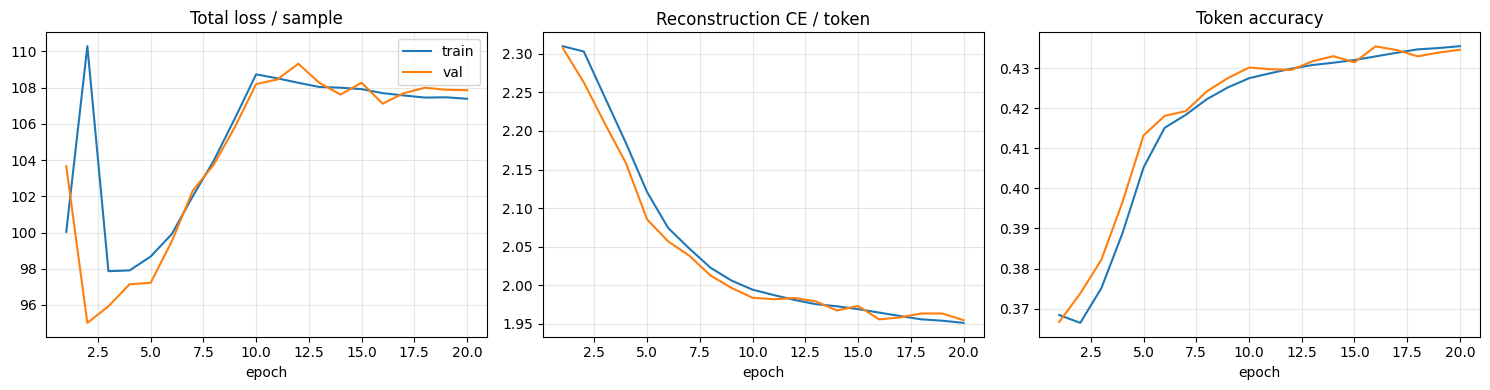

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs = np.arange(1, len(history["train_total"]) + 1)

axes[0].plot(epochs, history["train_total"], label="train")
axes[0].plot(epochs, history["val_total"], label="val")
axes[0].set_title("Total loss / sample")
axes[0].set_xlabel("epoch")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, history["train_recon_per_token"], label="train")
axes[1].plot(epochs, history["val_recon_per_token"], label="val")
axes[1].set_title("Reconstruction CE / token")
axes[1].set_xlabel("epoch")
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history["train_token_acc"], label="train")
axes[2].plot(epochs, history["val_token_acc"], label="val")
axes[2].set_title("Token accuracy")
axes[2].set_xlabel("epoch")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Quick reconstruction check

In [14]:
def decode_ids_to_selfies(ids: np.ndarray | list[int]) -> str:
    toks = []
    for idx in ids:
        tok = IDX_TO_TOKEN[int(idx)]
        if tok == EOS:
            break
        # Skip PAD and UNK for the final string representation
        if tok in [PAD, UNK]:
            continue
        toks.append(tok)
    return "".join(toks)


def show_reconstructions(n: int = 5, seed: int = 42):
    model.eval()

    rng = np.random.default_rng(seed)
    k = min(n, len(test_x))
    idxs = rng.choice(len(test_x), size=k, replace=False)

    # 1. Convert to integer IDs (LongTensor)
    x_ids = torch.from_numpy(test_x[idxs]).long().to(device)

    # --- CHANGE: REMOVED x_onehot conversion ---

    with torch.no_grad():
        # 2. Pass x_ids DIRECTLY to the model
        logits, _, _ = model(x_ids) 
        pred_ids = logits.argmax(dim=-1).cpu().numpy()

    for j, idx in enumerate(idxs):
        orig_selfies = test_selfies[idx]
        pred_selfies = decode_ids_to_selfies(pred_ids[j])
        exact = orig_selfies == pred_selfies
        
        print(f"[{j}] exact={exact}")
        print("orig:", orig_selfies)
        print("pred:", pred_selfies)
        print("-" * 30)


show_reconstructions(n=5, seed=SEED)


[0] exact=False
orig: [C][C][Branch1][C][C][C@H1][Branch1][C][C][C][N][C][=Branch1][C][=O][C][C][C][C@H1][C][C][C@@H1][Branch1][Ring2][C][Ring1][#Branch1][NH2+1][Ring1][=Branch1]
pred: [C][C][Branch1][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C]
------------------------------
[1] exact=False
orig: [C][C][C@@H1][Branch2][Ring1][=Branch1][O][C][=Branch1][C][=O][C][=C][C][=C][C][Branch1][#Branch1][N][C][Branch1][C][C][=O][=C][Ring1][#Branch2][C][=Branch1][C][=O][N][C][C][=C][Branch1][C][C][O][N][=Ring1][=Branch1]
pred: [C][C][Branch2][Ring1][Ring1][C][C][C][C][=O][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C]
------------------------------
[2] exact=False
orig: [Cl][C][C@H1][C][C][C][O][C@H1][Ring1][=Branch1][C][=C][C][=C][Branch1][C][Cl][S][Ring1][=Branch1]
pred: [NH3+1][C][C][C][C][=C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][Ring1][Ring1][Ring1]
----------------------------

### Notes for later tox21 post-training
This notebook now saves a new sequence-convolution checkpoint. Update the model definition in the post-training notebook before loading it, or keep using the older checkpoint if you want the old architecture.


### Temporary: continue training for +10 epochs from the latest checkpoint


In [14]:
EXTRA_EPOCHS = 10

resume_last_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_last.pt"
legacy_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}.pt"
resume_path = resume_last_path if resume_last_path.exists() else legacy_path

if not resume_path.exists():
    raise FileNotFoundError(
        f"Could not find a checkpoint to resume from. Checked: {resume_last_path} and {legacy_path}"
    )

print("Resuming from:", resume_path)
resume_bundle = torch.load(resume_path, map_location=device)

model_resume = PaperLikeSelfiesVAE(vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, latent_dim=LATENT_DIM).to(device)
model_resume.load_state_dict(resume_bundle["model_state_dict"])

optimizer_resume = torch.optim.Adam(model_resume.parameters(), lr=LR)
if resume_bundle.get("optimizer_state_dict") is not None:
    optimizer_resume.load_state_dict(resume_bundle["optimizer_state_dict"])
else:
    print("No optimizer state found in checkpoint; using fresh Adam optimizer.")

history_resume = resume_bundle.get("history")
if history_resume is not None and "beta" in history_resume:
    start_epoch = int(resume_bundle.get("epoch", len(history_resume["beta"])))
else:
    history_resume = None
    start_epoch = int(resume_bundle.get("epoch", 0))

print(f"Loaded start_epoch={start_epoch}. Will train through epoch {start_epoch + EXTRA_EPOCHS}.")


Resuming from: artifacts/pretraining_checkpoints/paper_like_selfies_chembl_zinc_seqconv_ce.pt
No optimizer state found in checkpoint; using fresh Adam optimizer.
Loaded start_epoch=20. Will train through epoch 30.


In [18]:
continued_run_name = f"{WANDB_RUN_NAME}-resume-{start_epoch + EXTRA_EPOCHS}"

model, history, checkpoint_info = train_model(
    train_x,
    val_x,
    model=model_resume,
    optimizer=optimizer_resume,
    history=history_resume,
    start_epoch=start_epoch,
    num_epochs=EXTRA_EPOCHS,
    checkpoint_dir=CHECKPOINT_DIR,
    checkpoint_stem=CHECKPOINT_STEM,
    save_epoch_checkpoints=SAVE_EPOCH_CHECKPOINTS,
    wandb_run_name=continued_run_name,
)

final_beta = history["beta"][-1]
test_metrics = evaluate(model, test_x, beta=final_beta)

final_epoch = len(history["beta"])
continuation_ckpt_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_continued_to_epoch_{final_epoch:03d}.pt"
torch.save(
    _checkpoint_payload(
        model,
        history,
        epoch=final_epoch,
        best_epoch=checkpoint_info["best_epoch"],
        best_val_total=checkpoint_info["best_val_total"],
        optimizer=optimizer_resume,
        test_metrics=test_metrics,
    ),
    continuation_ckpt_path,
)

# Refresh *_last with test metrics from the continued model.
torch.save(
    _checkpoint_payload(
        model,
        history,
        epoch=final_epoch,
        best_epoch=checkpoint_info["best_epoch"],
        best_val_total=checkpoint_info["best_val_total"],
        optimizer=optimizer_resume,
        test_metrics=test_metrics,
    ),
    CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_last.pt",
)

pd.DataFrame(
    [
        {
            "start_epoch": start_epoch,
            "end_epoch": final_epoch,
            "best_epoch": checkpoint_info["best_epoch"],
            "best_val_total": checkpoint_info["best_val_total"],
            "test_total": test_metrics["total"],
            "test_token_acc": test_metrics["token_acc"],
            "checkpoint_best": str(CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_best.pt"),
            "checkpoint_last": str(CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_last.pt"),
            "checkpoint_continued": str(continuation_ckpt_path),
        }
    ]
)


epoch 021 | beta=1.00 | train total=56.0645 | val total=77.4692 | train token acc=0.7892 | val token acc=0.6110
epoch 022 | beta=1.00 | train total=53.1101 | val total=50.7707 | train token acc=0.8100 | val token acc=0.8273 | new best
epoch 023 | beta=1.00 | train total=51.2929 | val total=55.4964 | train token acc=0.8231 | val token acc=0.7942
epoch 024 | beta=1.00 | train total=60.8528 | val total=55.0665 | train token acc=0.7556 | val token acc=0.7953
epoch 025 | beta=1.00 | train total=56.4252 | val total=50.6999 | train token acc=0.7876 | val token acc=0.8292 | new best
epoch 026 | beta=1.00 | train total=50.3565 | val total=48.3512 | train token acc=0.8310 | val token acc=0.8460 | new best
epoch 027 | beta=1.00 | train total=56.6366 | val total=48.9069 | train token acc=0.7875 | val token acc=0.8425
epoch 028 | beta=1.00 | train total=57.1128 | val total=48.1932 | train token acc=0.7827 | val token acc=0.8479 | new best
epoch 029 | beta=1.00 | train total=58.0130 | val total=50.0

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best/epoch,▁▃▃▃▅▅▅▇▇█
best/val_total,█▆▆▆▆▃▃▃▃▁
beta,▁▁▁▁▁▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
train/kl,▇██▆▄▅▃▃▂▁
train/recon_per_token,▅▄▃█▆▂▆▆▆▁
train/token_acc,▄▅▆▁▃▇▃▃▃█
train/total,▅▄▃█▆▂▆▆▆▁
val/kl,█▅▆▂▃▄▄▃▁▂
val/recon_per_token,█▂▃▃▂▂▂▂▂▁
+2,...


,start_epoch,end_epoch,best_epoch,best_val_total,test_total,test_token_acc,checkpoint_best,checkpoint_last,checkpoint_continued
0,20,30,30,45.675472,45.803002,0.867677,artifacts/pretraining_checkpoints/paper_like_s...,artifacts/pretraining_checkpoints/paper_like_s...,artifacts/pretraining_checkpoints/paper_like_s...


# Test on Tox 21 test set!

## XGBoost on tox21 using VAE latent features
Use the best pretrained VAE checkpoint to extract latent means (`mu`) from tox21 SMILES, then train one XGBoost classifier per tox21 task.

In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
)

# 1. PATHS & LOADING
TOX21_TRAIN_PATH = Path("data") / "Train" / "tox21_train_clean.csv"
TOX21_VAL_PATH = Path("data") / "Val" / "tox21_val_clean.csv"
TOX21_TEST_PATH = Path("data") / "Test" / "tox21_test_clean.csv"

best_ckpt_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_best.pt"
if not best_ckpt_path.exists():
    raise FileNotFoundError(f"Best checkpoint not found: {best_ckpt_path}")

# Load the bundle
bundle = torch.load(best_ckpt_path, map_location=device)

# --- ARCHITECTURE CHECK ---
print("--- Architecture Verification ---")
# Check metadata saved in payload
layout = bundle.get("encoder_layout", "Unknown")
print(f"Metadata Layout: {layout}")

# Initialize model
model_best = PaperLikeSelfiesVAE(vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, latent_dim=LATENT_DIM).to(device)
model_best.load_state_dict(bundle["model_state_dict"])
model_best.eval()

# Check internal layers
if hasattr(model_best, 'encoder_gru'):
    print("✅ Verified: Model contains 'encoder_gru'.")
    print(f"   Hidden Size: {model_best.encoder_gru.hidden_size}")
    print(f"   Bidirectional: {model_best.encoder_gru.bidirectional}")
else:
    print("❌ Warning: 'encoder_gru' not found. This may be the old CNN architecture.")

if hasattr(model_best, 'embedding'):
    print("✅ Verified: Model contains 'embedding' layer for integer input.")
# ---------------------------

TASKS = [c for c in pd.read_csv(TOX21_TRAIN_PATH, nrows=1).columns if c.startswith("NR-") or c.startswith("SR-")]

def _smiles_to_ids_for_vocab(smiles: str):
    try:
        s = sf.encoder(smiles)
        toks = list(sf.split_selfies(s))
    except Exception:
        return None

    if len(toks) > MAX_LEN:
        return None

    # Use UNK_IDX for tokens not seen during pre-training
    ids = [TOKEN_TO_IDX.get(tok, UNK_IDX) for tok in toks[:MAX_LEN]]
    ids.append(EOS_IDX)

    arr = np.full(SEQ_LEN, PAD_IDX, dtype=np.int64)
    arr[:len(ids)] = ids
    return arr

def build_latent_split(csv_path: Path, task_cols: list[str], batch_size: int = 512):
    df = pd.read_csv(csv_path).dropna(subset=["canonical_smiles"]).reset_index(drop=True)
    y_all = df[task_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)

    x_ids_list, y_kept = [], []
    failed = 0
    for smi, y in zip(df["canonical_smiles"].astype(str).tolist(), y_all):
        ids = _smiles_to_ids_for_vocab(smi)
        if ids is None:
            failed += 1
            continue
        x_ids_list.append(ids)
        y_kept.append(y)

    x_ids = np.stack(x_ids_list)
    y = np.stack(y_kept)

    z_chunks = []
    with torch.no_grad():
        for i in range(0, len(x_ids), batch_size):
            # Pass integer IDs directly (LongTensor)
            xb = torch.from_numpy(x_ids[i:i + batch_size]).long().to(device)
            
            # The GRU encoder expects [Batch, Seq_Len] integers
            mean, _ = model_best.encoder(xb)
            z_chunks.append(mean.cpu().numpy())

    z = np.vstack(z_chunks)
    return z, y, failed

# Generate Matrices
Z_train, Y_train, fail_train = build_latent_split(TOX21_TRAIN_PATH, TASKS)
Z_val, Y_val, fail_val = build_latent_split(TOX21_VAL_PATH, TASKS)
Z_test, Y_test, fail_test = build_latent_split(TOX21_TEST_PATH, TASKS)

print("\n--- Feature Matrix Results ---")
print(f"train: Z={Z_train.shape}, Y={Y_train.shape}, skipped={fail_train}")
print(f"val  : Z={Z_val.shape}, Y={Y_val.shape}, skipped={fail_val}")
print(f"test : Z={Z_test.shape}, Y={Y_test.shape}, skipped={fail_test}")

C:\Users\Taha\AppData\Local\Temp\ipykernel_8256\2002933618.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  bundle = torch.load(best_ckpt_path, map_location=device)


--- Architecture Verification ---
Metadata Layout: bidirectional_gru_embedding
✅ Verified: Model contains 'encoder_gru'.
   Hidden Size: 256
   Bidirectional: True
✅ Verified: Model contains 'embedding' layer for integer input.

--- Feature Matrix Results ---
train: Z=(6237, 292), Y=(6237, 12), skipped=21
val  : Z=(770, 292), Y=(770, 12), skipped=12
test : Z=(765, 292), Y=(765, 12), skipped=18


In [19]:
task_rows = []
roc_curves = {}
pr_curves = {}

for j, task in enumerate(TASKS):
    ytr, yv, yt = Y_train[:, j], Y_val[:, j], Y_test[:, j]

    mtr = np.isin(ytr, [0, 1])
    mv = np.isin(yv, [0, 1])
    mt = np.isin(yt, [0, 1])

    # Need both classes for training and evaluation
    if len(np.unique(ytr[mtr])) < 2 or len(np.unique(yt[mt])) < 2:
        continue

    clf = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1,
    )
    clf.fit(Z_train[mtr], ytr[mtr], eval_set=[(Z_val[mv], yv[mv])], verbose=False)

    p_val = clf.predict_proba(Z_val[mv])[:, 1]
    thresholds = np.linspace(0.05, 0.95, 19)
    best_t = max(
        thresholds,
        key=lambda t: f1_score(yv[mv], (p_val >= t).astype(int), zero_division=0),
    )

    p_test = clf.predict_proba(Z_test[mt])[:, 1]
    y_true = yt[mt].astype(int)
    y_hat = (p_test >= best_t).astype(int)

    auroc = roc_auc_score(y_true, p_test)
    auprc = average_precision_score(y_true, p_test)

    task_rows.append(
        {
            "task": task,
            "n_test": int(mt.sum()),
            "threshold": float(best_t),
            "AUROC": float(auroc),
            "AUPRC": float(auprc),
            "Accuracy": float(accuracy_score(y_true, y_hat)),
            "F1": float(f1_score(y_true, y_hat, zero_division=0)),
            "Precision": float(precision_score(y_true, y_hat, zero_division=0)),
            "Recall": float(recall_score(y_true, y_hat, zero_division=0)),
        }
    )

    fpr, tpr, _ = roc_curve(y_true, p_test)
    prec, rec, _ = precision_recall_curve(y_true, p_test)
    roc_curves[task] = (fpr, tpr, auroc)
    pr_curves[task] = (rec, prec, auprc, float(y_true.mean()))

metrics_df = pd.DataFrame(task_rows).sort_values("AUROC", ascending=False).reset_index(drop=True)
metrics_df

,task,n_test,threshold,AUROC,AUPRC,Accuracy,F1,Precision,Recall
0,NR-AR-LBD,765,0.10,0.725131,0.270632,0.958170,0.272727,0.240000,0.315789
1,NR-AhR,765,0.10,0.666205,0.200603,0.688889,0.278788,0.192469,0.505495
2,NR-AR,765,0.25,0.635892,0.245091,0.958170,0.238095,0.294118,0.200000
3,NR-ER-LBD,765,0.25,0.626344,0.154145,0.966013,0.133333,0.222222,0.095238
4,NR-ER,765,0.20,0.616951,0.194063,0.861438,0.196970,0.203125,0.191176
5,SR-MMP,765,0.05,0.616213,0.181091,0.484967,0.259398,0.157534,0.734043
6,NR-Aromatase,765,0.05,0.609572,0.178612,0.881046,0.180180,0.153846,0.217391
7,NR-PPAR-gamma,765,0.05,0.606632,0.053554,0.958170,0.058824,0.083333,0.045455
8,SR-HSE,765,0.05,0.601582,0.109139,0.822222,0.160494,0.113043,0.276596
9,SR-ATAD5,765,0.15,0.586289,0.053692,0.937255,0.040000,0.055556,0.031250


In [20]:
print("Macro average metrics:")
metrics_df[["AUROC", "AUPRC", "Accuracy", "F1", "Precision", "Recall"]].mean().to_frame("macro_mean").T

Macro average metrics:


,AUROC,AUPRC,Accuracy,F1,Precision,Recall
macro_mean,0.61608,0.161466,0.809259,0.19073,0.169231,0.302002


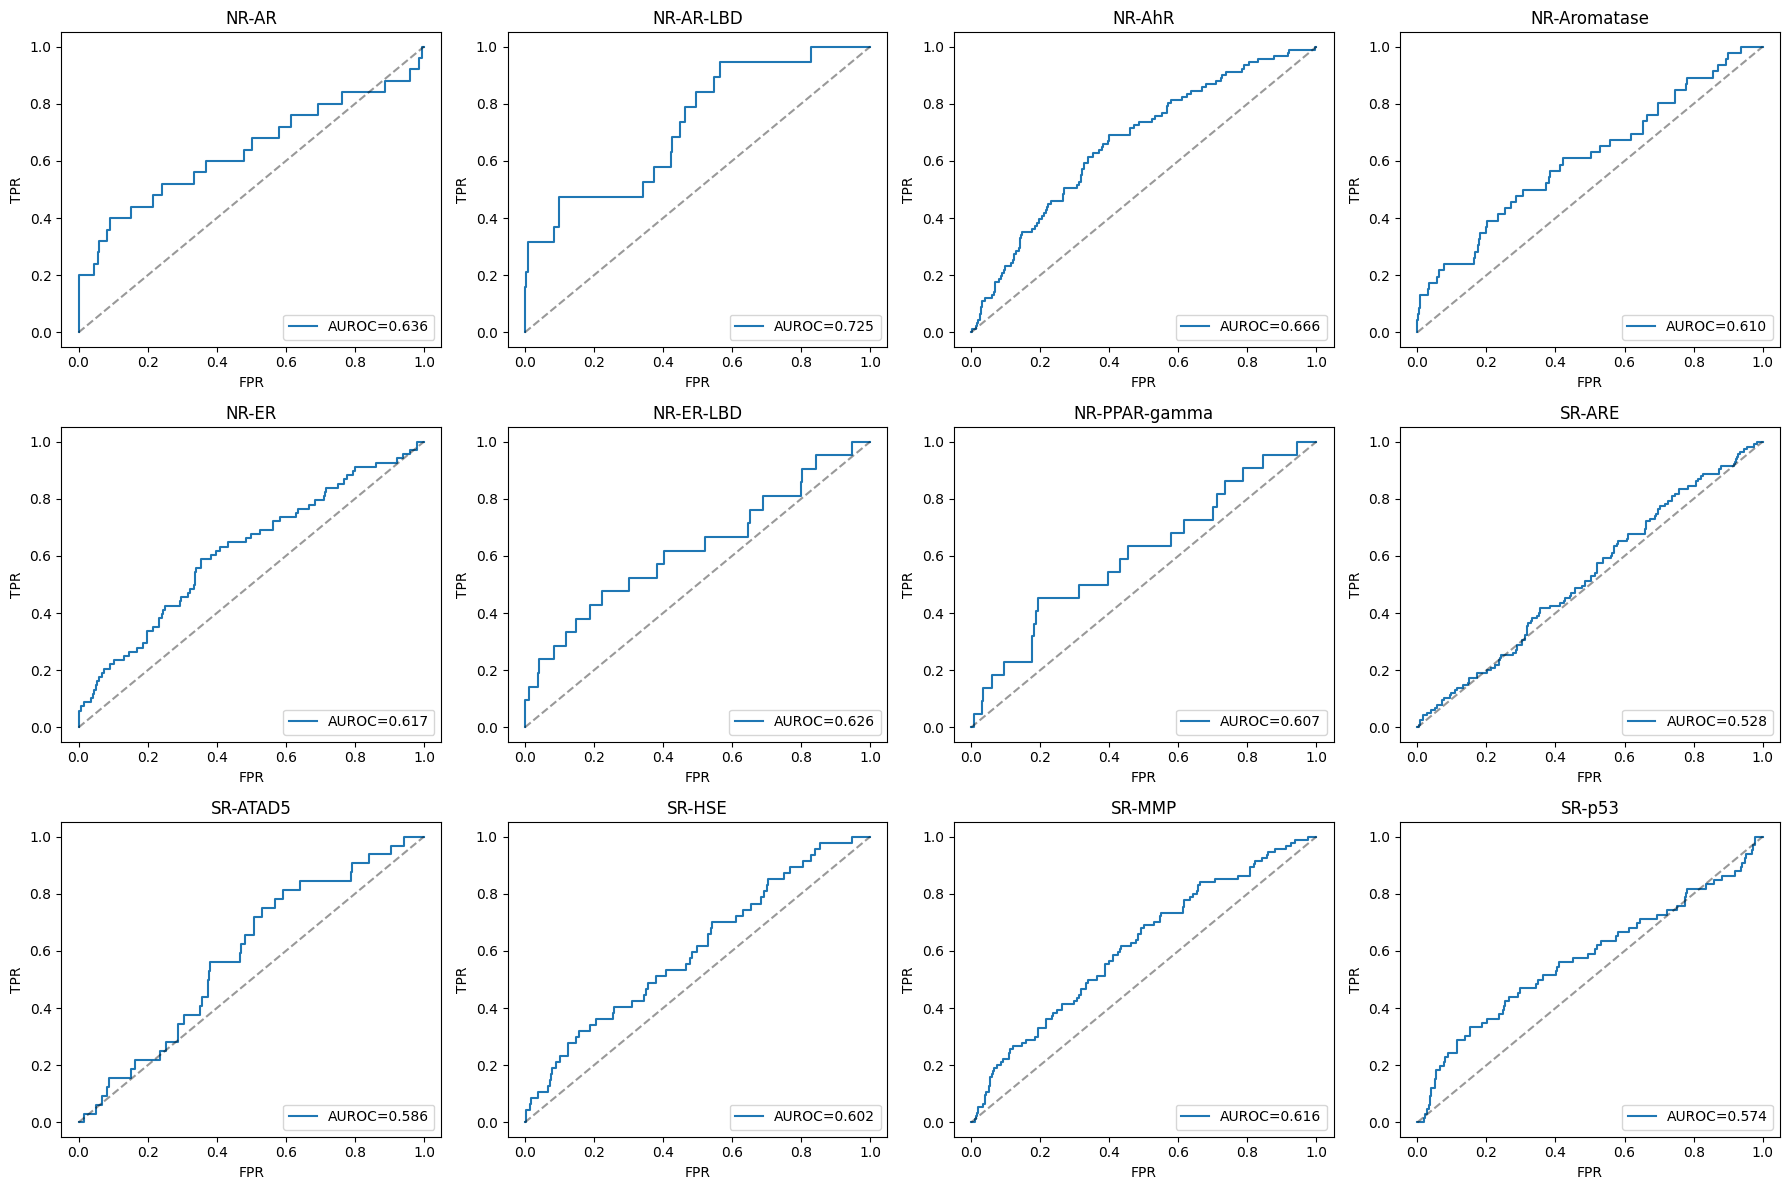

In [21]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, task in zip(axes.ravel(), TASKS):
    if task in roc_curves:
        fpr, tpr, auc = roc_curves[task]
        ax.plot(fpr, tpr, label=f"AUROC={auc:.3f}")
        ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
        ax.set_title(task)
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.legend(loc="lower right")
    else:
        ax.set_title(task)
        ax.text(0.5, 0.5, "insufficient class variation", ha="center", va="center")
        ax.axis("off")

plt.tight_layout()
plt.show()

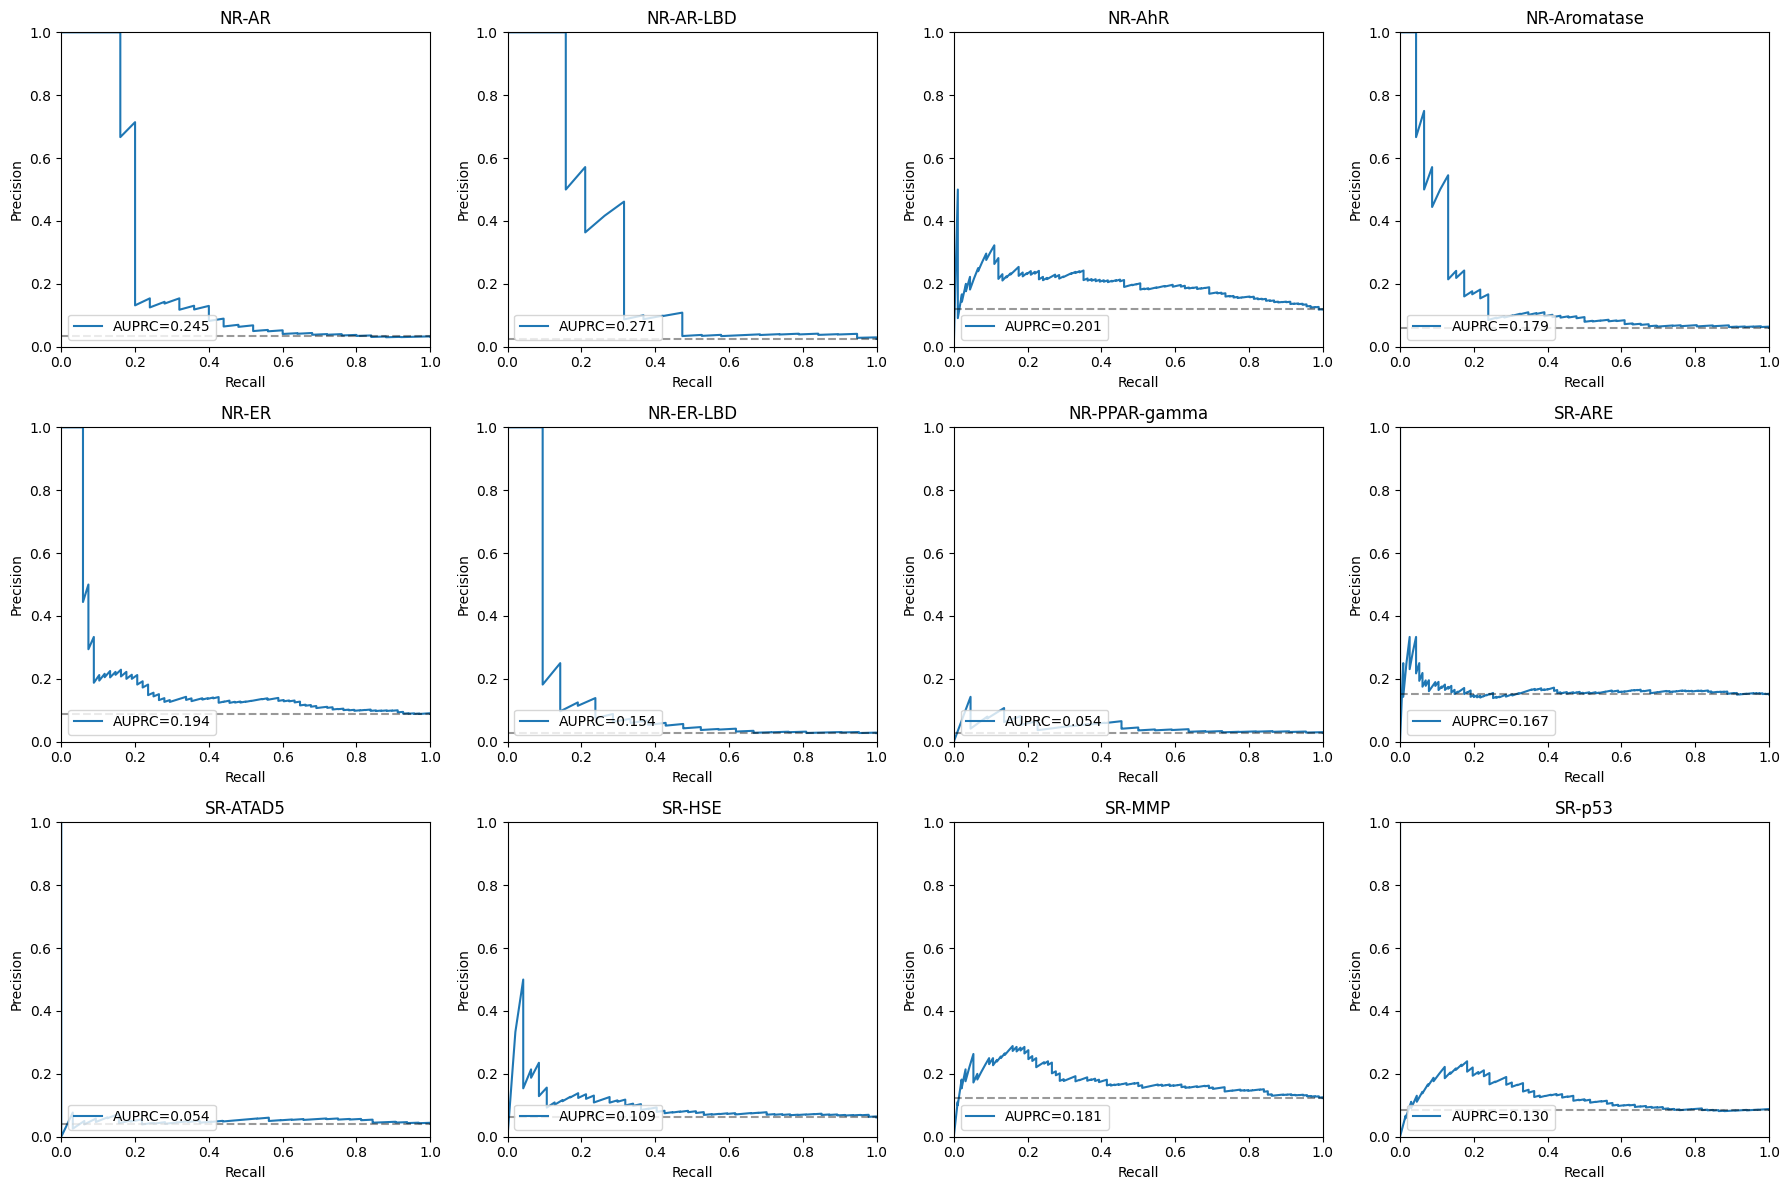

In [22]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, task in zip(axes.ravel(), TASKS):
    if task in pr_curves:
        rec, prec, ap, base = pr_curves[task]
        ax.plot(rec, prec, label=f"AUPRC={ap:.3f}")
        ax.hlines(base, 0, 1, colors="k", linestyles="--", alpha=0.4)
        ax.set_title(task)
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(loc="lower left")
    else:
        ax.set_title(task)
        ax.text(0.5, 0.5, "insufficient class variation", ha="center", va="center")
        ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# Tox21 test token accuracy using BEST pretrained checkpoint
TOX21_TEST_PATH = Path("data") / "Test" / "tox21_test_clean.csv"
best_ckpt_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_best.pt"

if not best_ckpt_path.exists():
    raise FileNotFoundError(f"Best checkpoint not found: {best_ckpt_path}")

# 1) Load tox21 test SMILES
tox21_test_df = pd.read_csv(TOX21_TEST_PATH)
tox21_test_smiles = tox21_test_df["canonical_smiles"].dropna().astype(str).tolist()
tox21_test_smiles = list(dict.fromkeys(tox21_test_smiles))

# 2) Convert + filter exactly like pretraining pipeline
tox21_test_selfies, tox21_failed = smiles_to_selfies(tox21_test_smiles)
tox21_test_selfies = filter_selfies_len(tox21_test_selfies, max_len=MAX_LEN)
tox21_test_x = encode_list(tox21_test_selfies)

# 3) Load best model weights
bundle = torch.load(best_ckpt_path, map_location=device)
model_best = PaperLikeSelfiesVAE(vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, latent_dim=LATENT_DIM).to(device)
model_best.load_state_dict(bundle["model_state_dict"])

# 4) Evaluate (same token-accuracy computation path as this notebook)
beta_eval = bundle["history"]["beta"][-1] if "history" in bundle and "beta" in bundle["history"] else 1.0
tox21_metrics = evaluate(model_best, tox21_test_x, beta=beta_eval)

print(f"Best checkpoint: {best_ckpt_path.name}")
print(f"Tox21 test SMILES: raw={len(tox21_test_smiles):,} | selfies_ok={len(tox21_test_selfies):,} | failed={tox21_failed:,}")
print(
    f"Tox21 test metrics -> "
    f"total={tox21_metrics['total']:.4f}, "
    f"recon_per_token={tox21_metrics['recon_per_token']:.4f}, "
    f"kl={tox21_metrics['kl']:.4f}, "
    f"token_acc={tox21_metrics['token_acc']:.4f}"
)

Best checkpoint: paper_like_selfies_chembl_zinc_seqconv_ce_best.pt
Tox21 test SMILES: raw=783 | selfies_ok=765 | failed=0
Tox21 test metrics -> total=68.5168, recon_per_token=0.9323, kl=29.2259, token_acc=0.7571
